# 1. Wprowadzenie
## Cel projektu
Celem projektu jest zbudowanie modelu klasyfikacyjnego przewidującego, czy roczny dochód danej osoby przekracza 50 000 USD, na podstawie danych demograficznych i zawodowych.

## Opis problemu naukowego
Problem klasyfikacji dochodów (Income Classification) na zbiorze *Adult* (znanym również jako *Census Income*) jest klasycznym zagadnieniem w uczeniu maszynowym. Zrozumienie czynników wpływających na wysokość zarobków ma kluczowe znaczenie w analizach ekonomicznych, socjologicznych oraz w marketingu celowanym. Model pozwoli zidentyfikować kluczowe cechy (takie jak wykształcenie, wiek, czy stan cywilny) korelujące z wyższym statusem materialnym.

# 2. Ekspolarcja i analiza danych
## Opis zbioru danych

Zbiór danych *Adult* pochodzi z bazy UCI Machine Learning Repository. Dane te zostały wyodrębnione z bazy danych spisu powszechnego USA z 1994 roku. Zbiór ten posiada ponad 48000 rekordów. Dane zawierają mieszankę zmiennych kategorycznych i numerycznych.

## Opis wszystkich zmiennych
Zbiór danych posiada 14 zmiennych objaśniających. W podanym zbiorze znajduje się 6 cech ciągłych oraz 8 cech kategorycznych. Natomiast posiada 1 zmienną celu.
### Zmienne kategoryczne
*   **workclass** (klasa zatrudnienia): Określa rodzaj pracodawcy lub status zatrudnienia.
*   **education** (wykształcenie): Najwyższy ukończony poziom edukacji.
*   **marital-status** (stan cywilny): Określa stan cywilny.
*   **occupation** (zawód): Rodzaj wykonywanej pracy.
*   **relationship** (relacja rodzina): Rola pełniona w gospodarstiwe domowym.
*   **race** (rasa): Pochodzenie etnicze.
*   **sex** (płeć): Określa płeć.
*   **native-country** (kraj pochodzenia): Kraj urodzenia. Większość rekordów pochodzi z USA

#### Zmienne ciągłe

*   **age** (wiek): Wiek wyrażony w latach.
*   **fnlwgt** (waga statystyczna): Określa szacowaną liczbę osób w populacji, która reprezentuje dany rekord.
*   **education-num** (liczba lat edukacji): Numer ten wyraża poziom wykształcenia.
*   **capital-gain** (zysk kapitałowy): Dochód pochodzący z innych źródeł niż praca zarobkowa.
*   **capital-loss** (strata kapitałowa): Strata finansowa poniesiona na inwestycjach.
*   **hours-per-week** (godziny pracy): Średnia liczba godzin przepracowanych w tygodniu.

####Zmienna celu

*   **income** (dochód): Określa czy dana osoba jest w stanie zarobić 50k.

In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
# pobieranie dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

In [ ]:
# Przykładowe dane z dataset
df = pd.concat([X, y], axis=1)
df.head(15)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
print("Liczba obserwacji: ", df.shape[0])
print("Liczba zmiennych: ", df.shape[1])
df.info()

Liczba obserwacji:  48842
Liczba zmiennych:  15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## Analiza zmiennych kategorycznych

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    print(f"\n--- Column: {col} ---")
    value_counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100

    combined_info = pd.DataFrame({
        'Count': value_counts,
        'Percentage': percentages.round(2)
    })
    print(combined_info)


--- Column: workclass ---
                  Count  Percentage
workclass                          
Private           33906       69.42
Self-emp-not-inc   3862        7.91
Local-gov          3136        6.42
State-gov          1981        4.06
?                  1836        3.76
Self-emp-inc       1695        3.47
Federal-gov        1432        2.93
NaN                 963        1.97
Without-pay          21        0.04
Never-worked         10        0.02

--- Column: education ---
              Count  Percentage
education                      
HS-grad       15784       32.32
Some-college  10878       22.27
Bachelors      8025       16.43
Masters        2657        5.44
Assoc-voc      2061        4.22
11th           1812        3.71
Assoc-acdm     1601        3.28
10th           1389        2.84
7th-8th         955        1.96
Prof-school     834        1.71
9th             756        1.55
12th            657        1.35
Doctorate       594        1.22
5th-6th         509        1.04
1s

**Wiele zmiennych wykazuje silną nierównowagę :**

* **Native-country**: Jest ekstremalnie zdominowana przez wartość "United-States", która stanowi blisko 90% wszystkich obserwacji. Meksyk, będący drugim najczęstszym krajem, stanowi niecałe 2% danych.

* **Race**: Zmienna ta jest zdominowana przez kategorię "White" (ponad 85%), podczas gdy druga w kolejności kategoria "Black" stanowi około 9.6%.

* **Workclass**: Sektor prywatny "Private" obejmuje zdecydowaną większość pracowników (ok. 70%).

## Analiza brakujących wartości i wartości odstających



In [ ]:
missing = pd.DataFrame({
    'isNull': df.isnull().sum(),
    '?': df.isin(['?']).sum(),
    '%': ((df.isnull().sum() + df.isin(['?']).sum())/ len(df) * 100).round(2)
})
missing

,isNull,?,%
age,0,0,0.00
workclass,963,1836,5.73
fnlwgt,0,0,0.00
education,0,0,0.00
education-num,0,0,0.00
marital-status,0,0,0.00
occupation,966,1843,5.75
relationship,0,0,0.00
race,0,0,0.00
sex,0,0,0.00


In [ ]:
print("Liczba '?' w danych:", df.isin(['?']).sum().sum())
print("Liczba NaN:", df.isnull().sum().sum())
df = df.replace('?', np.nan)

Liczba '?' w danych: 4262
Liczba NaN: 2203


Zmienne **workclass** (rodzaj pracy) i **occupation** (zawód) mają niemal identyczną liczbę braków. Sugeruje to, że osoby, które nie mają przypisanej klasy pracy, nie mają również wpisanego zawodu. Całkowity odsetek braków jest dosyć niski co pozwala na zasotoswanie imputacji.

##Analiza statystyczna zmiennych.

In [ ]:
print(df.describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


## Zmiany na zbiorze danych
Wartości *income* posiadają cztery różne wartości (<=50K, <=50K., >50K, >50K.). Dlatego wartości *income* zostały oczyszczone z kropek.

In [ ]:
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
df.loc[df['income'].str.contains('>'), 'income'] = '>50K'
df.loc[df['income'] != '>50K', 'income'] = '<=50K'

In [ ]:
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


## Identyfikacja kluczowych zależności

* **Wykształcenie**: Osoby z wyższym wykształceniem mają większe szanse na zarobki >50k
* **Wiek**: Dochód zmienia się w przewidywalny sposób wraz z wiekiem. Osoby w wieku średnim mają swój szczyt zarobkowy.
* **Stan cywilny**: Osoby będące w związku małżeńskim zarabiają znacznie lepiej niż pozostałe grupy.
* **Godziny pracy**: Osoby wyrabiające większą ilość godzin są w stanie zarobić więcej.
* **Zawód**: Osoby zajmujące stanowiska kierownicze są w stanie zarobić ponad 50k


# 3. Wizualizacja danych

In [ ]:
# Ustawienie stylu i rozmiaru czcionek dla czytelności
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Wizualizacja rozkładów wszystkich zmiennych
### Rozkład zmiennej celu

/tmp/ipython-input-3963910520.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='viridis')


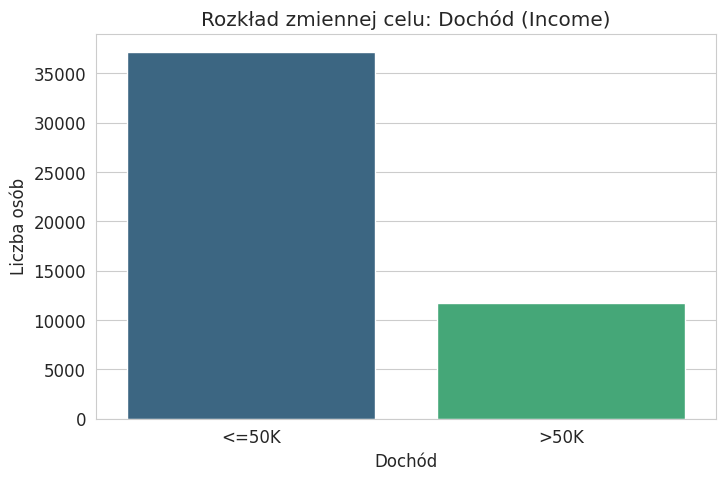

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='income', data=df, palette='viridis')
plt.title('Rozkład zmiennej celu: Dochód (Income)')
plt.xlabel('Dochód')
plt.ylabel('Liczba osób')
plt.show()


### Rozkład zmiennych ciągłych

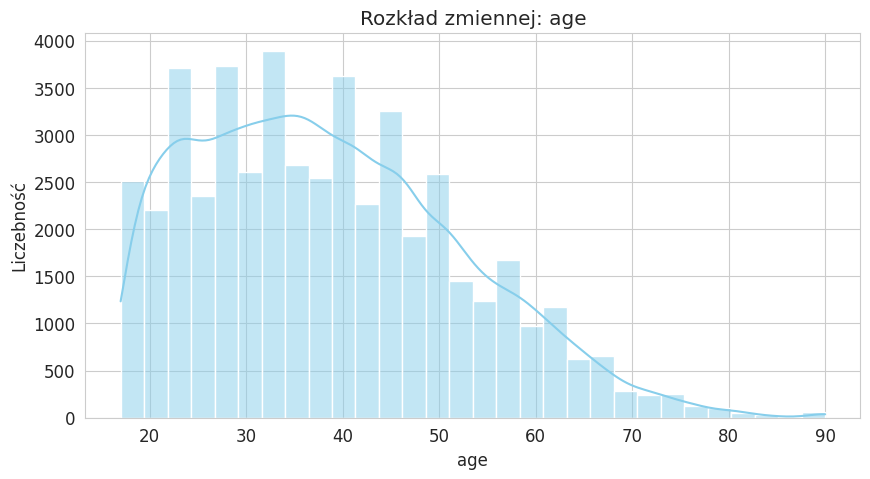

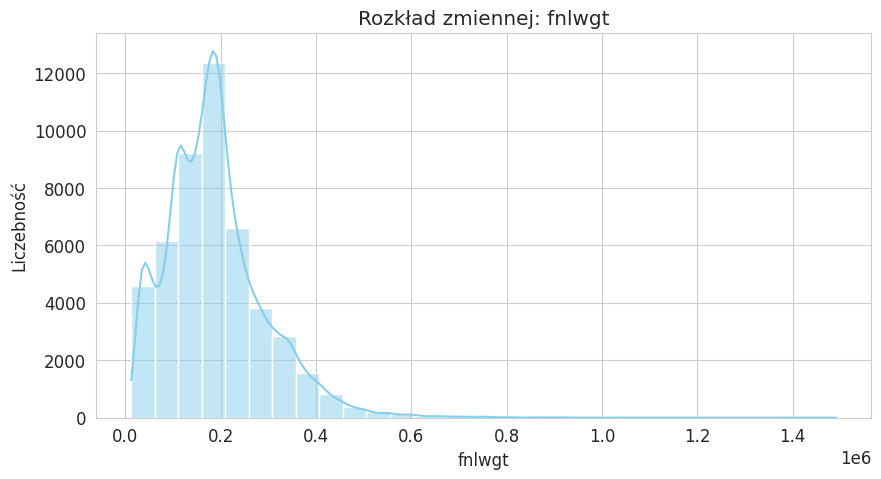

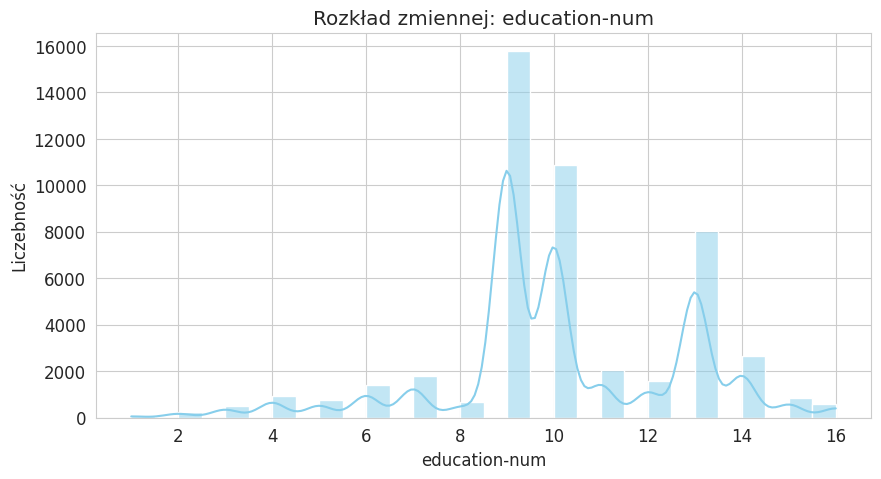

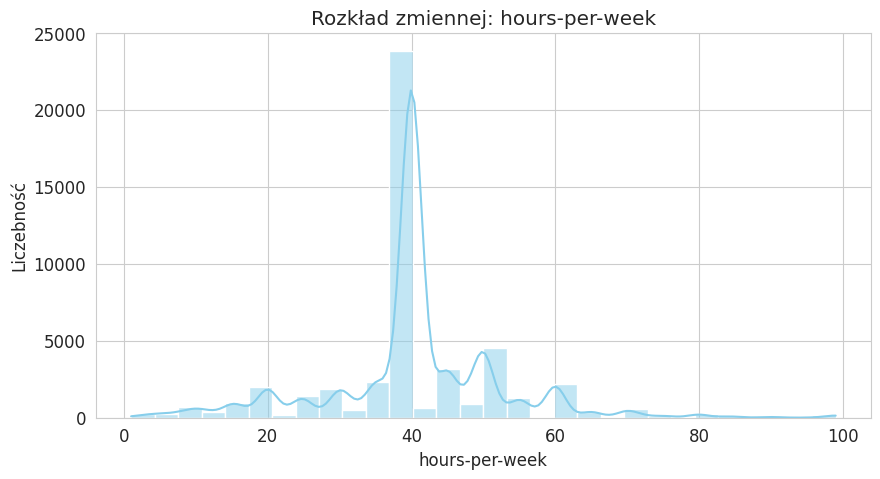

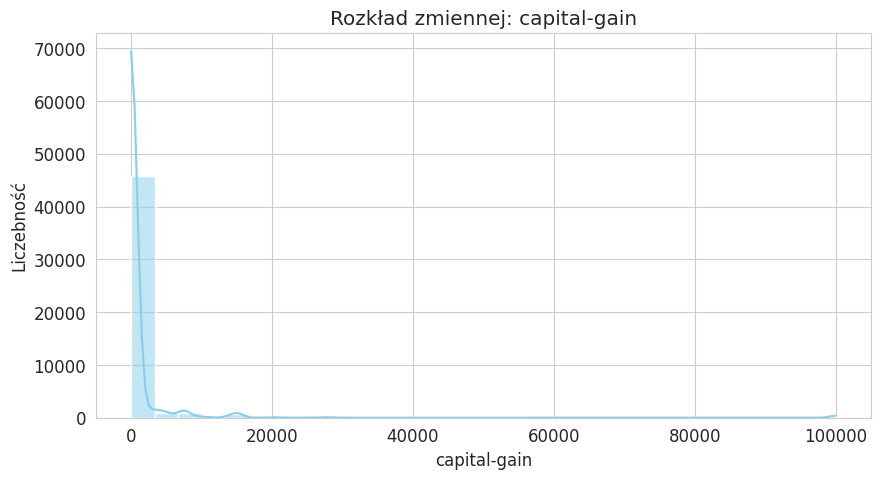

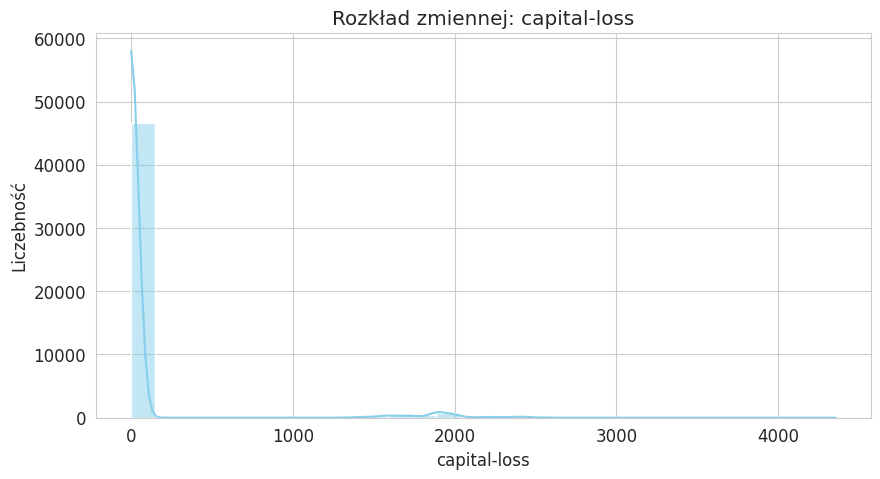

In [ ]:
continuous_vars = ['age', 'fnlwgt', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']

# Rysowanie wszystkich zmiennych ciągłych w pętli
for col in continuous_vars:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Rozkład zmiennej: {col}')
    plt.xlabel(col)
    plt.ylabel('Liczebność')
    plt.show()


#### **age (wiek)**:
Najwięcej osób w zbiorze danych to osoby młode (między 20 a 40 rokiem życia). Liczba obserwacji maleje wraz z wiekiem. Sugeruje to, że siła robocza w badanym okresie składała się głównie z osób młodszych i w średnim wieku.

#### **fnlwgt (waga statystyczna)**:

Większość rekordów ma niską wagę statystyczną. Zmienna ta jest używana do szacowania populacji i zazwyczaj nie wykazuje silnej korelacji predykcyjnej z poziomem dochodu, co widać po jej nieregularnym, mocno skupionym przy lewej krawędzi rozkładzie.

#### **education-num (liczba lat edukacji)**:

Widać wyraźne piki przy wartościach odpowiadających typowym etapom edukacji: 9 lat (High School), 10 lat (Some-college), 13 lat (Bachelor's). Rozkład nie jest ciągły w tradycyjnym sensie, lecz dyskretny, odzwierciedlający system szkolnictwa USA. Wyższe wartości (powyżej 12) są rzadsze, ale mogą silnie korelować z wyższym dochodem.

#### **hours-per-week (godziny pracy na tydzień)**:

Zdecydowana większość osób pracuje w standardowym wymiarze 40 godzin tygodniowo (pełny etat). Widać również mniejsze skupiska przy 50 lub 60 godzinach (nadgodziny) oraz poniżej 40 (pół etatu). Jest to zmienna o małej wariancji dla większości populacji, ale odchylenia od normy mogą być istotne dla modelu.

#### **capital-gain (zysk kapitałowy) oraz capital-loss (strata kapitałowa)**:

Wnioski: Dla przytłaczającej większości osób (ok. 90%+) zysk lub strata kapitałowa wynosi 0. aktywnie. Dodatkowo wartości niezerowe mogą być bardzo silnym sygnałem predykcyjnym (np. wysoki zysk kapitałowy prawie na pewno oznacza wysoki dochód), ale ze względu na dominację zer, zmienne te mogą wymagać specjalnego traktowania (np. zamiany na zmienną binarną "czy posiada kapitał").


### Rozkład zmiennych kategorycznych

/tmp/ipython-input-1723977339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='muted')


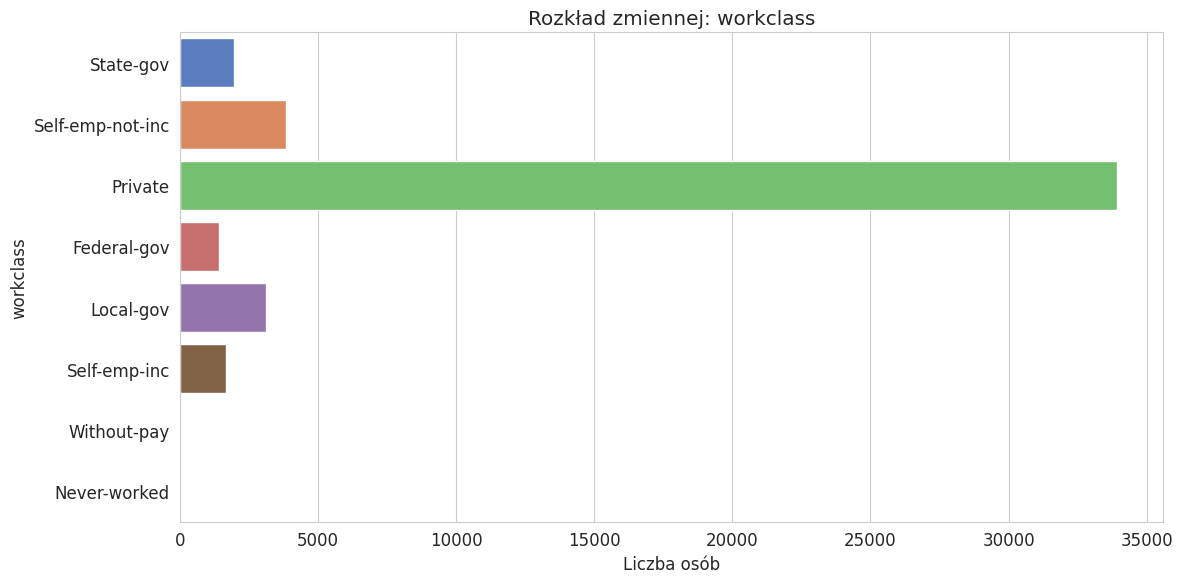

/tmp/ipython-input-1723977339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=top_categories, palette='muted')


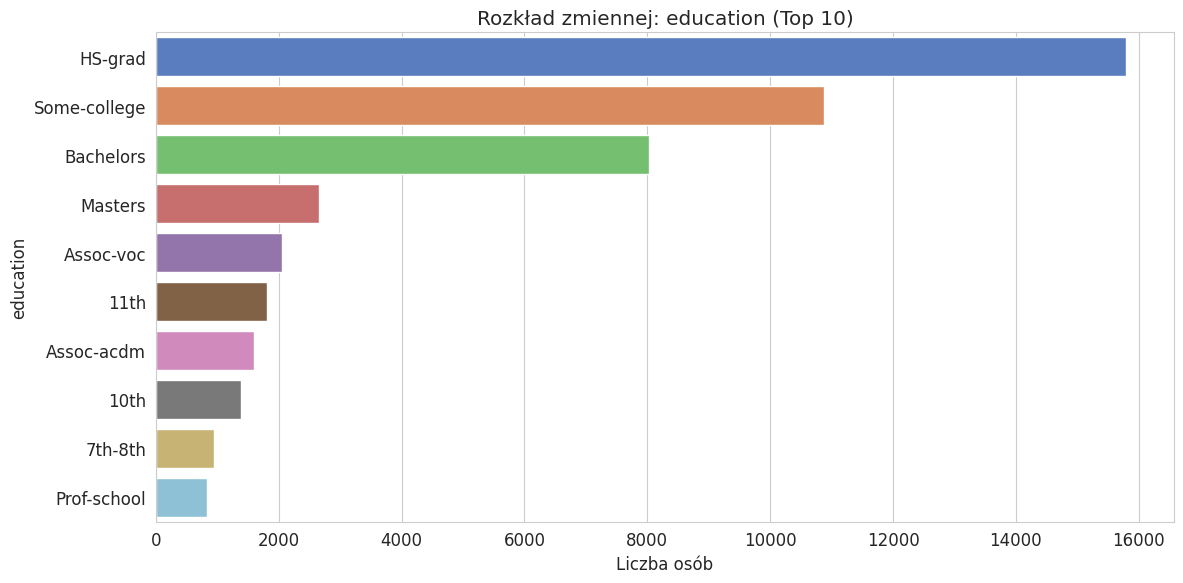

/tmp/ipython-input-1723977339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='muted')


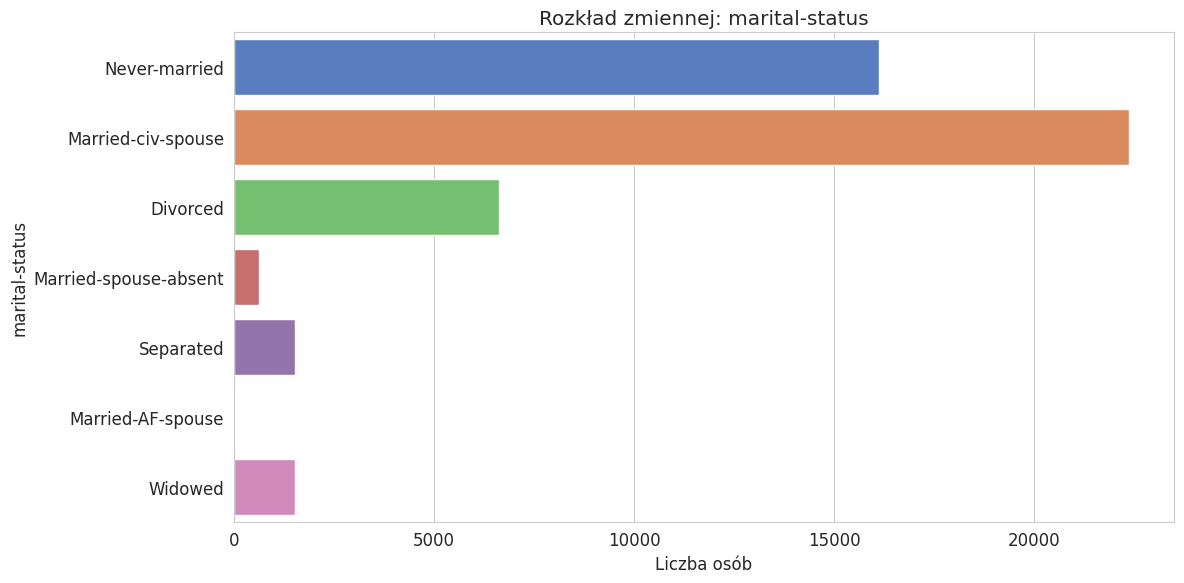

/tmp/ipython-input-1723977339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=top_categories, palette='muted')


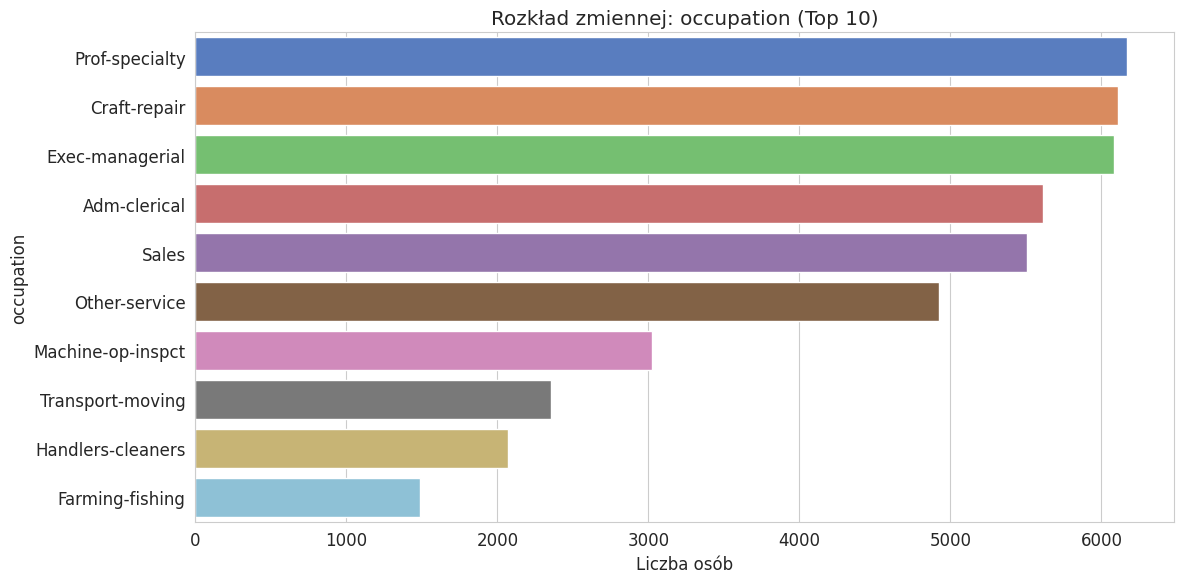

/tmp/ipython-input-1723977339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='muted')


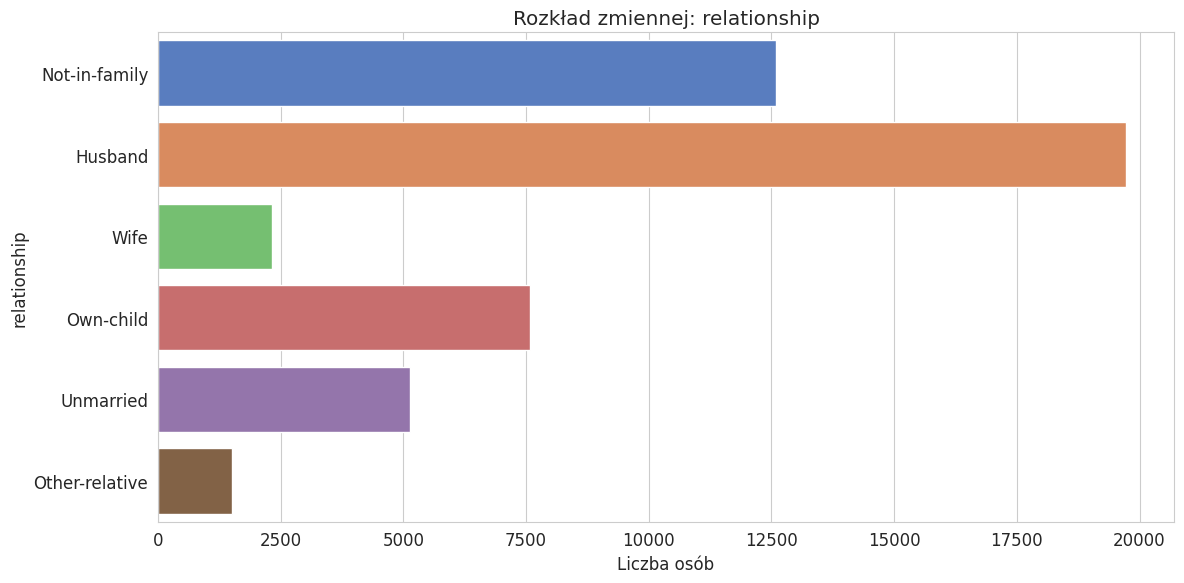

/tmp/ipython-input-1723977339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='muted')


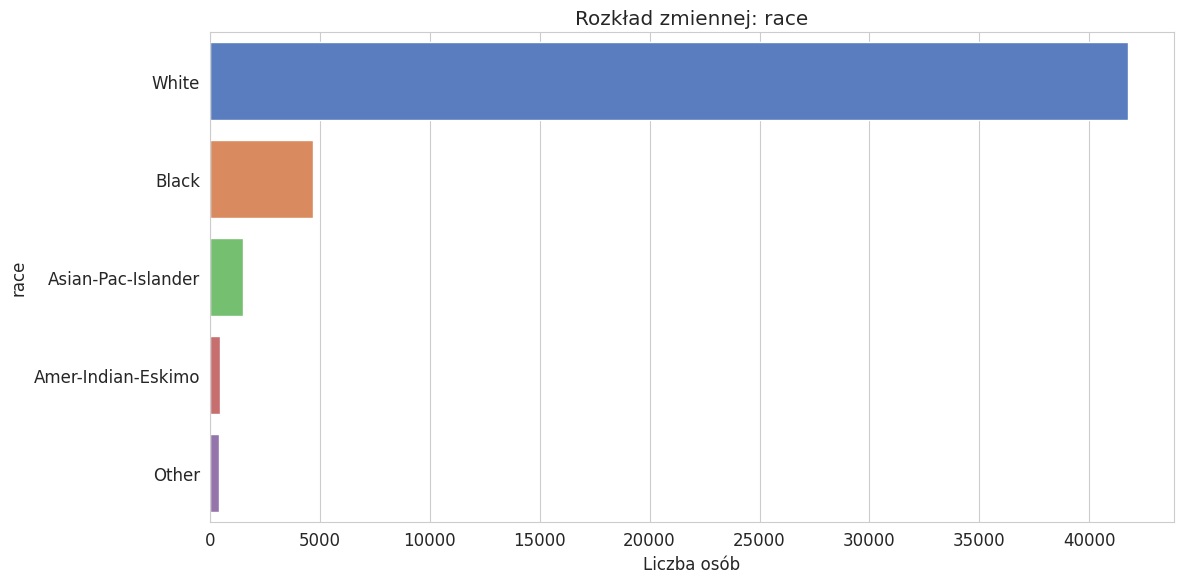

/tmp/ipython-input-1723977339.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, palette='muted')


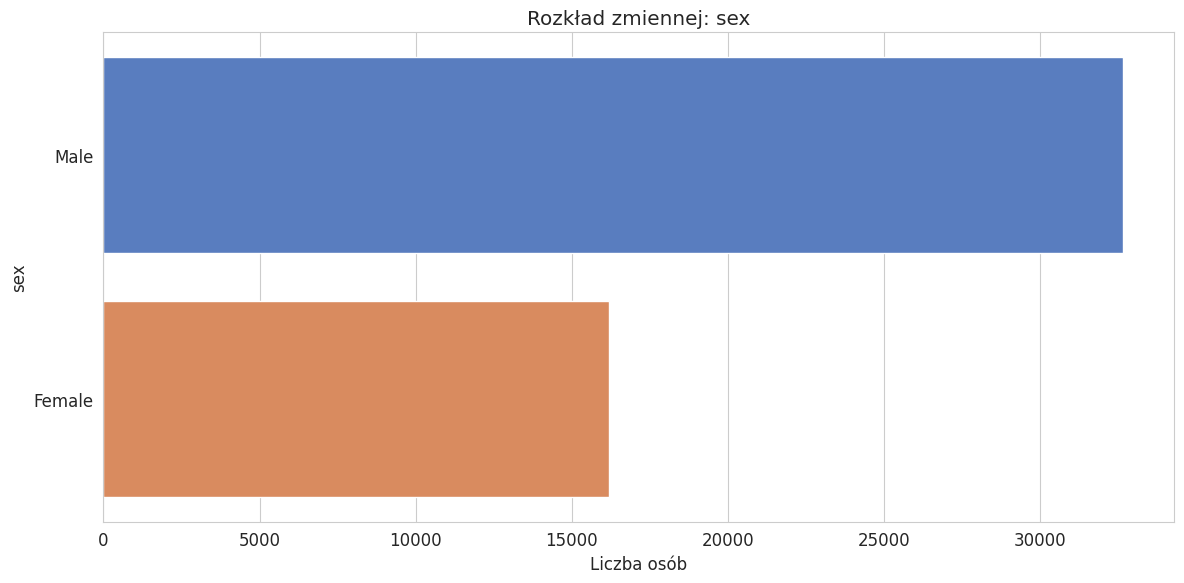

/tmp/ipython-input-1723977339.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=top_categories, palette='muted')


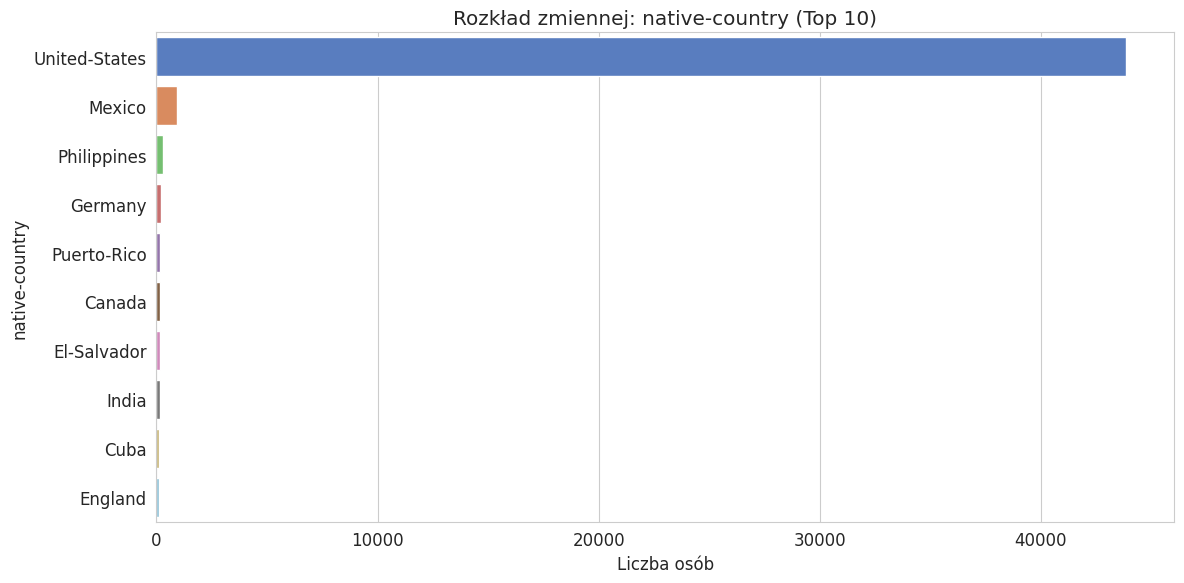

In [ ]:
categorical_vars = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

for col in categorical_vars:
    plt.figure(figsize=(12, 6))

    # Dla zmiennych z dużą liczbą kategorii (np. native-country) pokazujemy top 10
    if df[col].nunique() > 10:
        top_categories = df[col].value_counts().index[:10]
        sns.countplot(y=col, data=df, order=top_categories, palette='muted')
        plt.title(f'Rozkład zmiennej: {col} (Top 10)')
    else:
        sns.countplot(y=col, data=df, palette='muted')
        plt.title(f'Rozkład zmiennej: {col}')

    plt.xlabel('Liczba osób')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


#### **workclass (rodzaj zatrudnienia):**
Zdecydowana większość osób w zbiorze zatrudniona jest w sektorze prywatnym ("Private"). Pozostałe kategorie, takie jak samozatrudnienie czy praca w administracji rządowej (lokalnej, stanowej, federalnej), stanowią znacznie mniejszy odsetek, nie przekraczając łącznie 30% populacji.

#### **education (wykształcenie):**
Najliczniejszą grupę stanowią osoby z wykształceniem średnim ("HS-grad"), a następnie osoby, które rozpoczęły studia, ale ich nie ukończyły ("Some-college") oraz posiadacze licencjatu ("Bachelors"). Rozkład ten potwierdza obserwacje ze zmiennej numerycznej education-num – większość populacji kończy edukację na poziomie średnim lub niższym wyższym. Kategorie takie jak doktorat czy przedszkole są marginalne.

#### **marital-status (stan cywilny):**
Dominują osoby pozostające w związku małżeńskim ("Married-civ-spouse") oraz osoby, które nigdy nie wzięły ślubu ("Never-married"). Trzecią istotną grupą są rozwodnicy ("Divorced"). Taki rozkład sugeruje, że zmienna ta może być silnie skorelowana z wiekiem oraz dochodem, gdyż osoby w związkach małżeńskich statystycznie częściej znajdują się w stabilniejszej fazie kariery zawodowej.

#### **occupation (zawód):**
W przeciwieństwie do innych zmiennych, tutaj rozkład jest bardziej płaski wśród najpopularniejszych kategorii. Grupy takie jak specjaliści ("Prof-specialty"), rzemieślnicy ("Craft-repair") oraz kadra zarządzająca ("Exec-managerial") mają zbliżoną liczebność. Brak jednej dominującej profesji oznacza, że zmienna ta wnosi duże zróżnicowanie do modelu.

#### **relationship (relacja rodzinna):**
Najczęściej występującą kategorią jest "Husband", co jest spójne z dominacją mężczyzn w tym zbiorze danych. Druga co do wielkości grupa to "Not-in-family". Zmienna ta jest mocno powiązana ze stanem cywilnym i płcią, co może prowadzić do problemu współliniowości w modelach statystycznych, jeśli wszystkie te zmienne zostaną użyte jednocześnie.

#### **race (rasa):**
Zbiór danych wykazuje silne niezbalansowanie pod względem rasy. Około 85% obserwacji to osoby rasy białej. Druga w kolejności grupa, osoby czarnoskóre. Pozostałe grupy etniczne są reprezentowane w stopniu marginalnym, co może utrudniać modelowi poprawne generalizowanie wzorców dla mniejszości bez zastosowania odpowiednich technik balansowania danych.

#### **sex (płeć):**
Widoczna jest nadreprezentacja mężczyzn. Taka dysproporcja wynika ze specyfiki danych spisowych z 1994 roku, które koncentrowały się na osobach aktywnych zawodowo i generujących dochód, co w tamtym okresie częściej dotyczyło mężczyzn. Może to wprowadzać stronniczość w predykcjach modelu.

#### **native-country (kraj pochodzenia):**
Jest to zmienna o skrajnie niskiej wariancji – prawie 90% osób w zbiorze pochodzi ze Stanów Zjednoczonych. Meksyk, będący drugim najczęstszym krajem pochodzenia, stanowi zaledwie ok. 2% obserwacji.

### Macierz korelacji dla zmiennych ciągłych

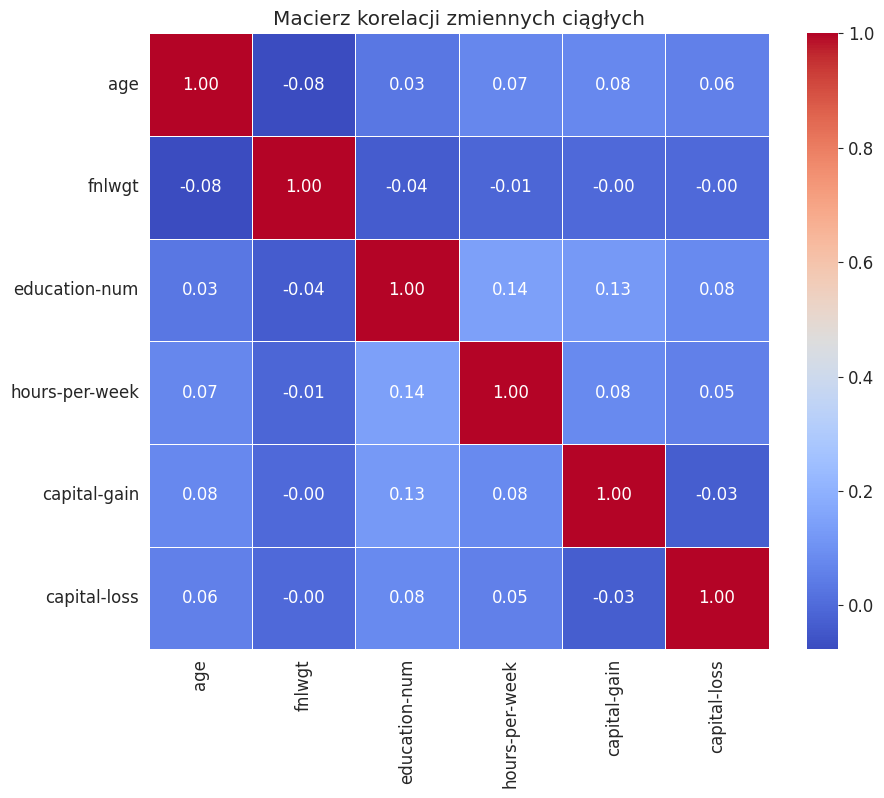

In [ ]:
plt.figure(figsize=(10, 8))
# Obliczamy korelację tylko dla kolumn numerycznych
corr_matrix = df[continuous_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji zmiennych ciągłych')
plt.show()


### Wykresy pudełkowe dla analizy zmiennych kategorycznych

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


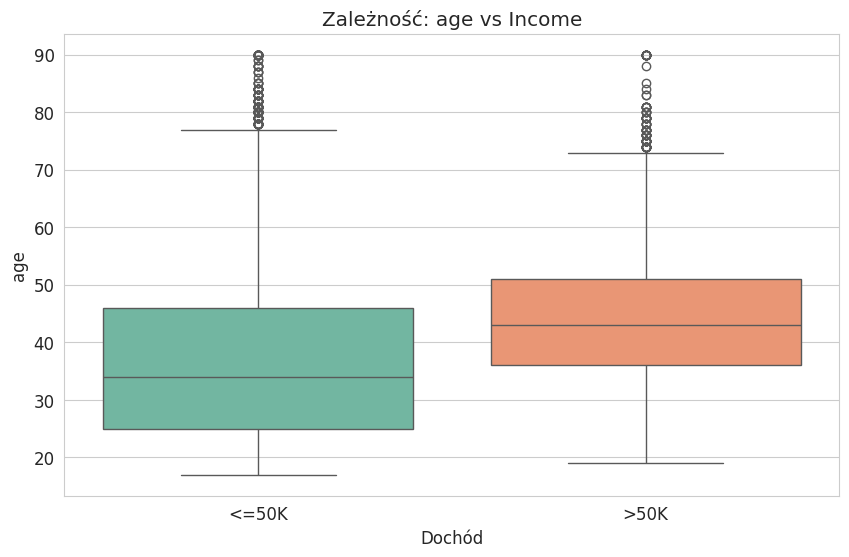

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


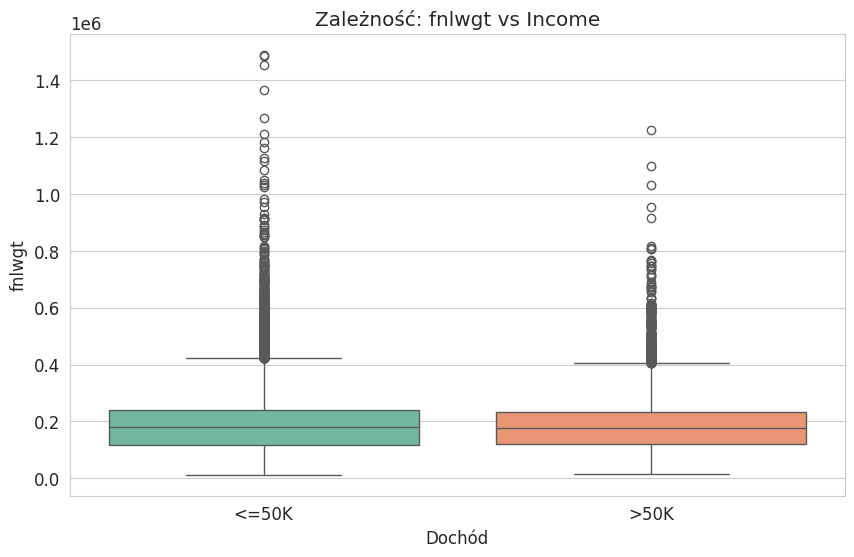

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


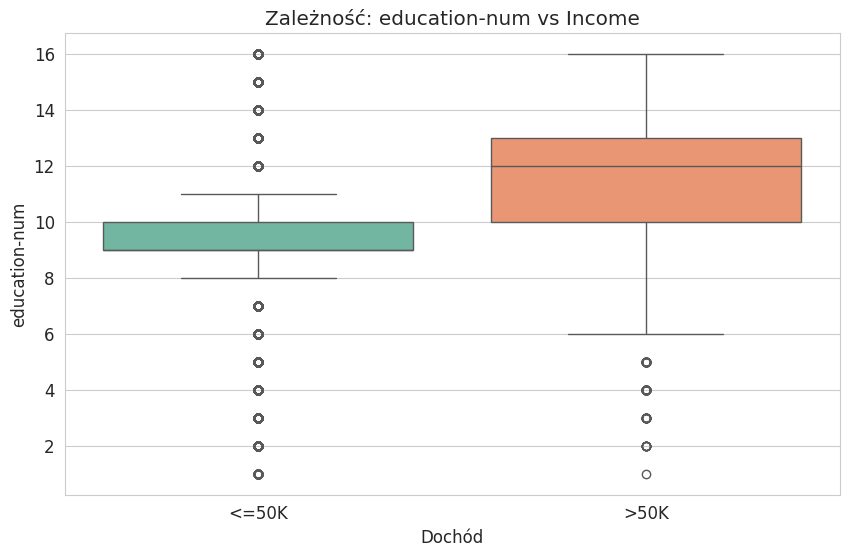

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


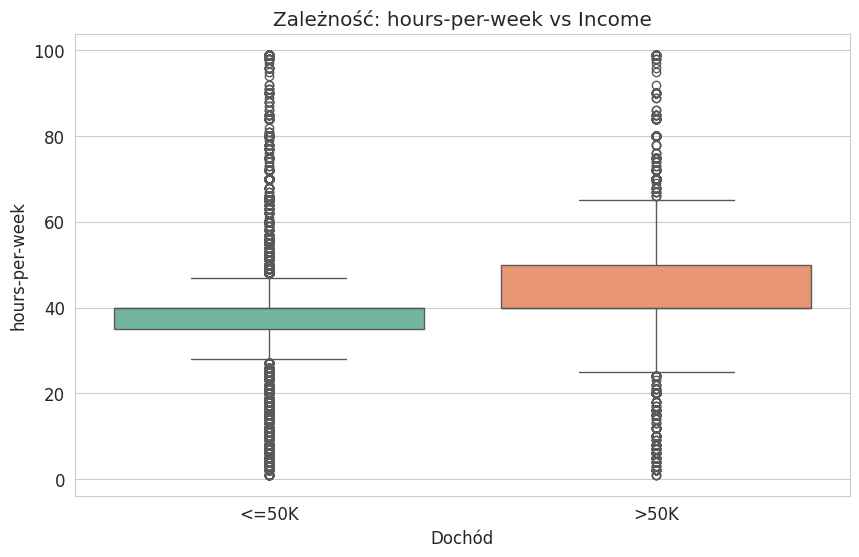

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


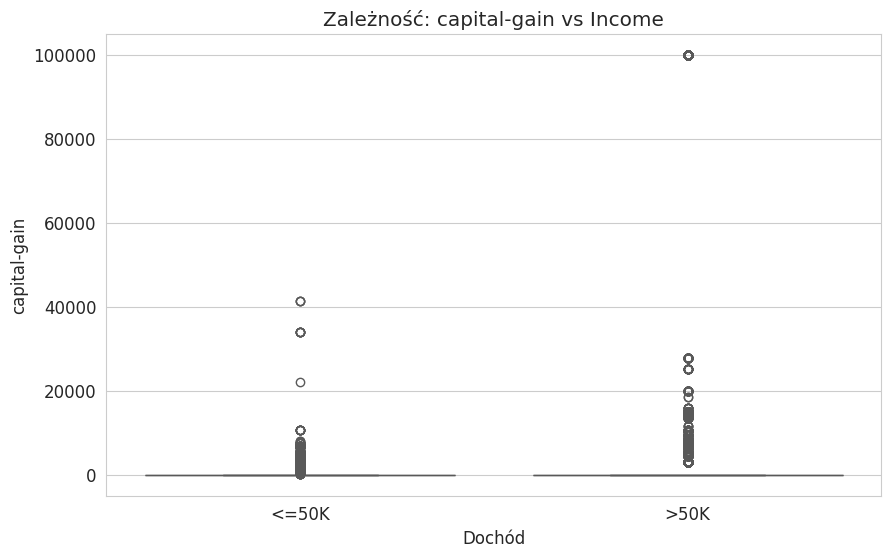

/tmp/ipython-input-1631099981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y=col, data=df, palette='Set2')


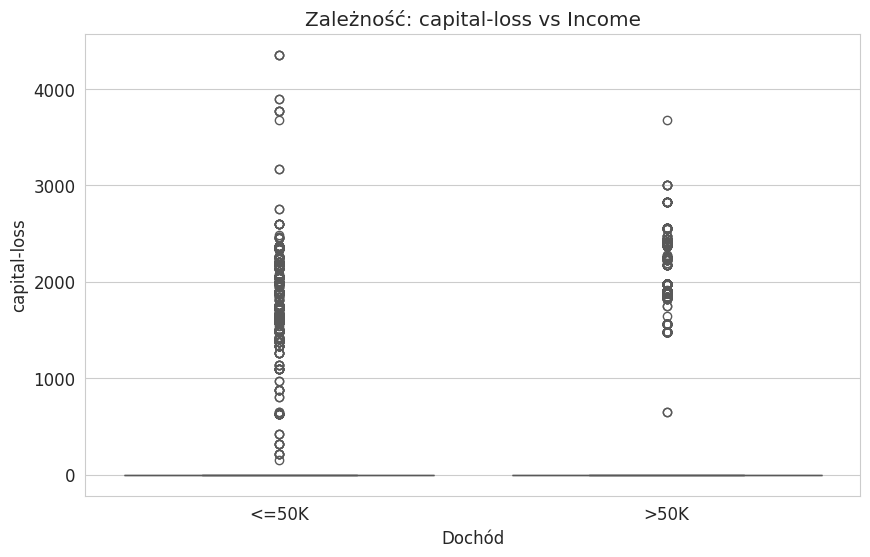

In [ ]:
for col in continuous_vars:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='income', y=col, data=df, palette='Set2')
    plt.title(f'Zależność: {col} vs Income')
    plt.xlabel('Dochód')
    plt.ylabel(col)
    plt.show()


### Wykresy zależności między zmiennymi objaśniającymi, a docelową

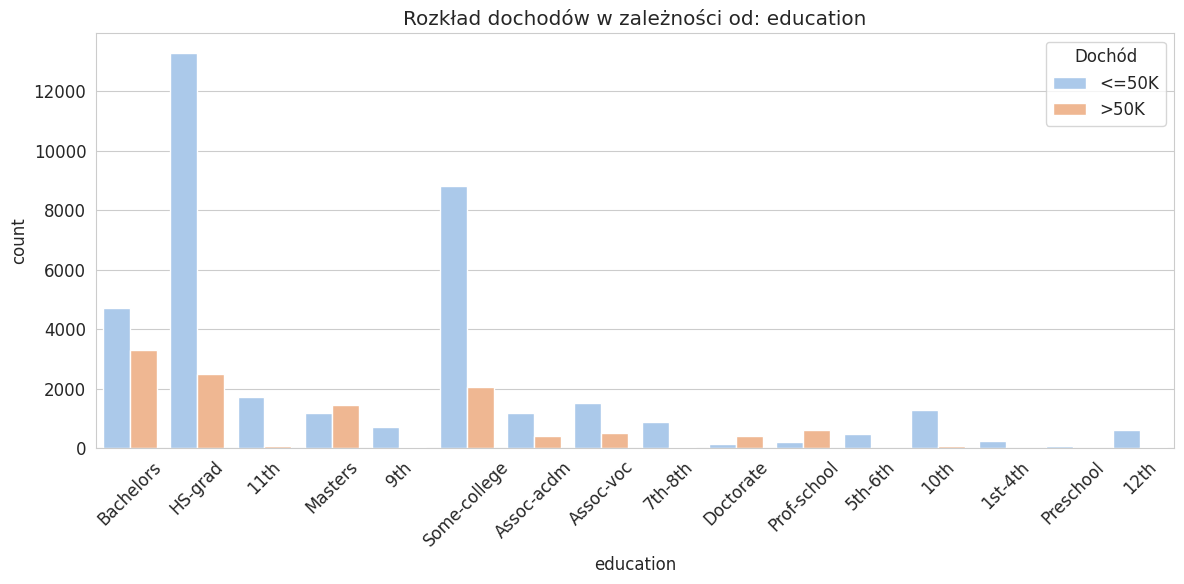

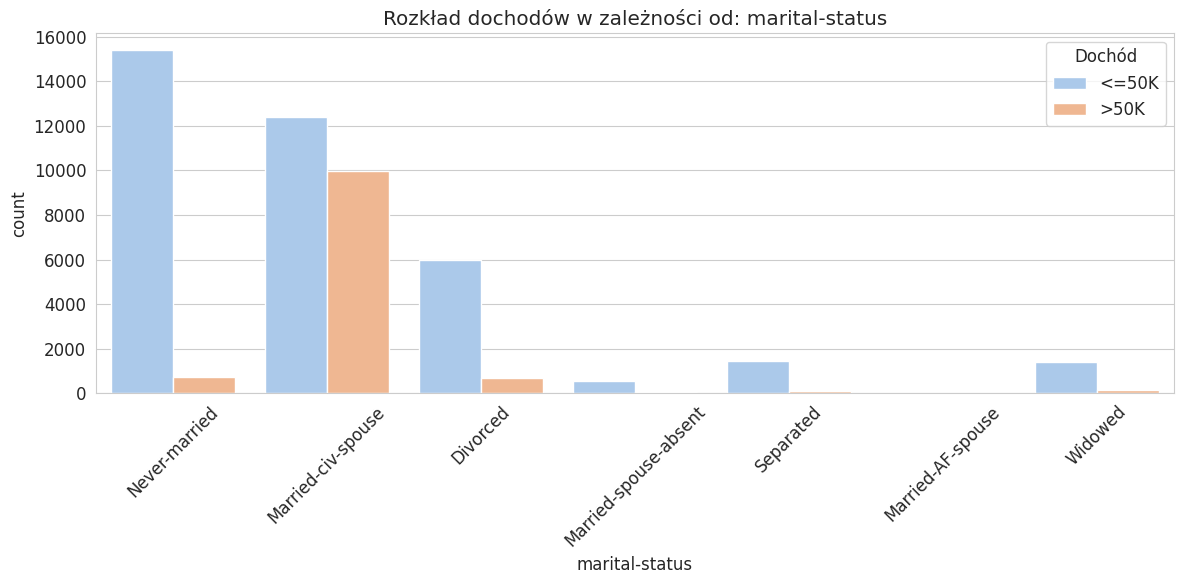

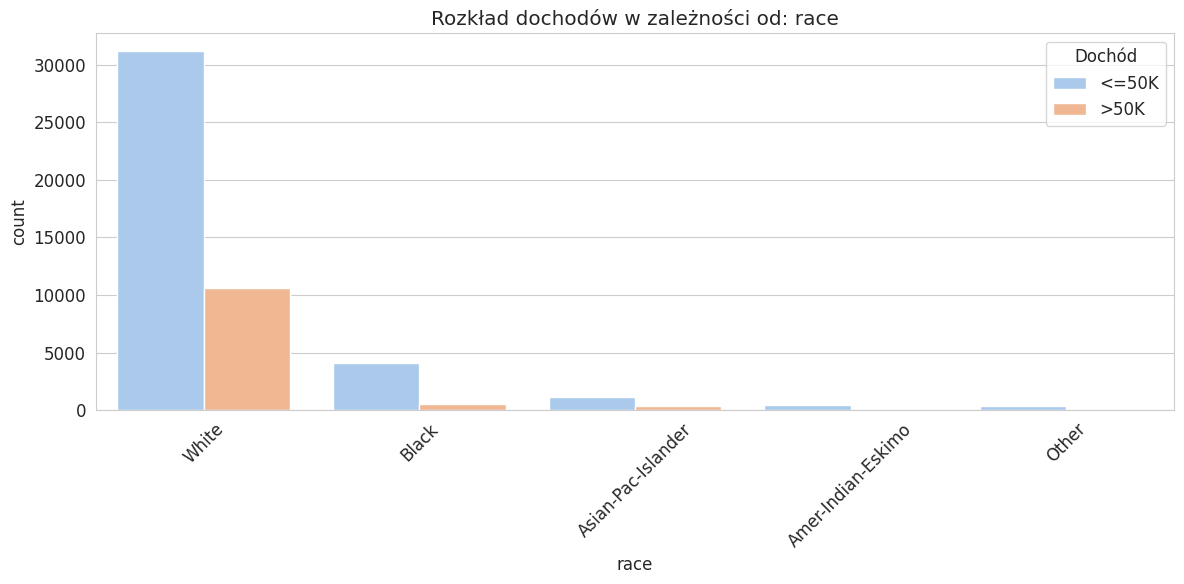

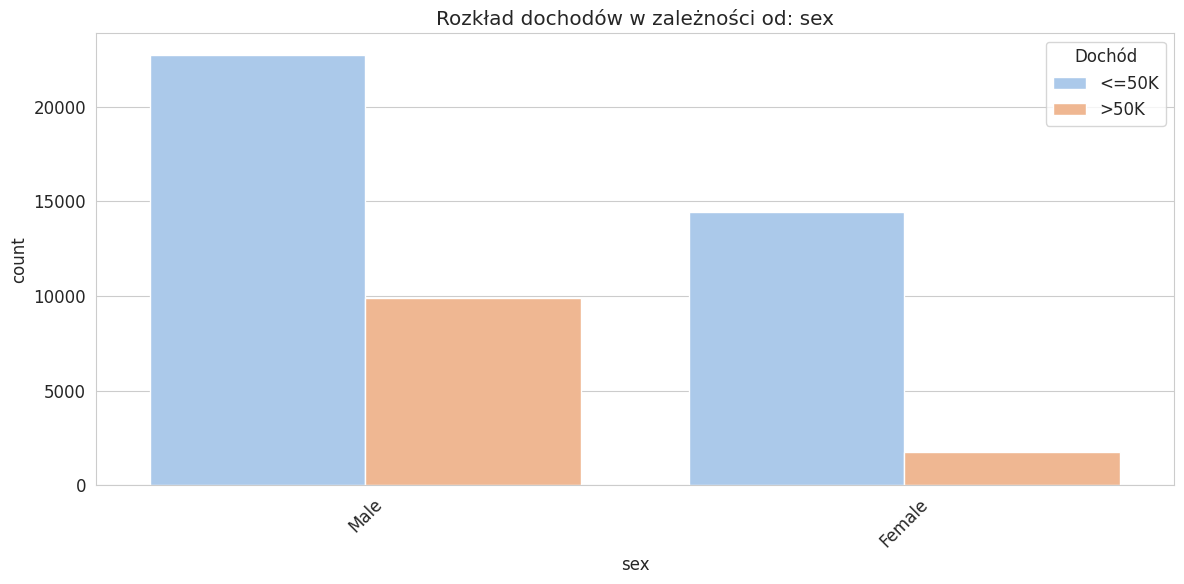

In [ ]:
# Wybór kilku kluczowych zmiennych kategorycznych do analizy zależności
key_categorical = ['education', 'marital-status', 'race', 'sex']

for col in key_categorical:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=col, hue='income', data=df, palette='pastel')
    plt.title(f'Rozkład dochodów w zależności od: {col}')
    plt.xticks(rotation=45)
    plt.legend(title='Dochód')
    plt.tight_layout()
    plt.show()


#4. Przetwarzanie danych

### Podział na zbiór treningowy i testowy

In [ ]:
X = df.drop('income', axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")
print(f"\nProporcje klas w zbiorze treningowym:\n{y_train.value_counts(normalize=True)}")
print(f"\nProporcje klas w zbiorze testowym:\n{y_test.value_counts(normalize=True)}")

Rozmiar zbioru treningowego: (39073, 14)
Rozmiar zbioru testowego: (9769, 14)

Proporcje klas w zbiorze treningowym:
income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

Proporcje klas w zbiorze testowym:
income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64


### Transformacja danych

In [ ]:
class DataCleanerTransformer(BaseEstimator, TransformerMixin):
  #Transformer czyszczący dane, zamienia '?' na NaN

  def fit(self, X, y=None):
    return self

  def transform():
    X = X.copy()
    X = X.replace('?', np.nan)
    return X

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
  """Transformator tworzący nowe cechy:
  1. has_capital - czy osoba ma jakikolwiek kapital
  2. relationship - upraszcza Husband/Wife do 'Married'
  """

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()

    if 'capital-gain' in X.columns and 'capital-loss' in X.columns:
      has_capital = ((X['capital-gain'] > 0) | (X['capital-loss'] > 0)).astype(int)
      X['has_capital'] = has_capital.replace({0: 'No', 1: 'Yes'})

    if 'relationship' in X.columns:
      X['relationship'] = X['relationship'].replace({'Husband':'Married', 'Wife':'Married'})

    return X

### Budowa i wykorzystanie pipelinea
nie robimy imputacji zmiennych numerycnzych bo nie występują braki

In [ ]:
numerical_features_base = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features_base = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

In [ ]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

full_pipeline = Pipeline(steps=[
    ('cleaner', FeatureEngineeringTransformer()),
    ('feature_eng', FeatureEngineeringTransformer()),
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', numerical_pipeline, numerical_features_base),
        ('cat', categorical_pipeline, categorical_features_base + ['has_capital'])
    ],
    verbose_feature_names_out=False))
])

X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# 5. Budowa modelu

## Wybór i uzasadnienie wybranych modeli

W celu rozwiązania problemu klasyfikacji dochodów, do eksperymentu wybrano trzy zróżnicowane algorytmy uczenia maszynowego. Wybór ten podyktowany jest chęcią porównania podejść o różnym stopniu złożoności (od modelu liniowego po zaawansowane metody zespołowe) oraz sprawdzenia, jak różne rodziny algorytmów radzą sobie ze specyfiką zbioru *Adult*.

Wybrane modele to:

1.  **Logistic Regression (Regresja Logistyczna)**
    Model ten został wybrany jako punkt odniesienia (**baseline**) dla bardziej złożonych algorytmów. Jest to klasyczna metoda statystyczna, charakteryzująca się dużą szybkością działania i prostotą implementacji. Jej kluczową zaletą jest wysoka **interpretowalność** – analiza wag przypisanych poszczególnym cechom pozwala łatwo zrozumieć wpływ zmiennych na predykcję.

2.  **Random Forest (Las Losowy)**
    Jako reprezentant metod zespołowych typu **bagging** (*bootstrap aggregating*), Random Forest jest naturalnym wyborem dla danych tabelarycznych. Model ten buduje wiele drzew decyzyjnych, a wynik końcowy jest uśrednieniem ich predykcji, co czyni go wysoce odpornym na zjawisko przeuczenia (**overfitting**) oraz redukuje wariancję błędu. Algorytm ten doskonale radzi sobie z **nieliniowymi zależnościami** między cechami i zazwyczaj nie wymaga skomplikowanego przetwarzania wstępnego, co czyni go stabilnym i wszechstronnym rozwiązaniem.

3.  **XGBoost (eXtreme Gradient Boosting)**
    Model ten wybrano jako reprezentanta metod typu **boosting** oraz obecny standard branżowy (**State-of-the-Art**) w konkursach Kaggle i zastosowaniach komercyjnych dla danych strukturyzowanych. XGBoost uczy się sekwencyjnie, korygując błędy poprzednich estymatorów, co często pozwala osiągnąć **najwyższą dokładność** klasyfikacji spośród testowanych metod.





## Procedura ewaluacji modeli (funkcja pomocnicza)

Aby zapewnić spójność i porównywalność wyników dla wszystkich testowanych algorytmów (Logistic Regression, Random Forest, XGBoost), zdefiniowano uniwersalną funkcję pomocniczą `evaluate_model`. Służy ona do kompleksowej oceny jakości klasyfikacji, eliminując konieczność powielania kodu dla każdego modelu z osobna.

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model", pos_label_metric='>50K'):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train, y_train_pred, pos_label=pos_label_metric),
        'test_precision': precision_score(y_test, y_test_pred, pos_label=pos_label_metric),
        'train_recall': recall_score(y_train, y_train_pred, pos_label=pos_label_metric),
        'test_recall': recall_score(y_test, y_test_pred, pos_label=pos_label_metric),
        'train_f1': f1_score(y_train, y_train_pred, pos_label=pos_label_metric),
        'test_f1': f1_score(y_test, y_test_pred, pos_label=pos_label_metric),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba)
    }

    print("="*70)
    print(f"OCENA MODELU: {model_name}")
    print("="*70)
    print("\nMETRYKI NA ZBIORZE TRENINGOWYM:")
    print(f"  • Accuracy (Dokładność):  {metrics['train_accuracy']:.4f}")
    print(f"  • Precision (Precyzja):   {metrics['train_precision']:.4f}")
    print(f"  • Recall (Czułość):       {metrics['train_recall']:.4f}")
    print(f"  • F1-Score:               {metrics['train_f1']:.4f}")
    print(f"  • ROC AUC:                {metrics['train_roc_auc']:.4f}")

    print("\nMETRYKI NA ZBIORZE TESTOWYM:")
    print(f"  • Accuracy (Dokładność):  {metrics['test_accuracy']:.4f}")
    print(f"  • Precision (Precyzja):   {metrics['test_precision']:.4f}")
    print(f"  • Recall (Czułość):       {metrics['test_recall']:.4f}")
    print(f"  • F1-Score:               {metrics['test_f1']:.4f}")
    print(f"  • ROC AUC:                {metrics['test_roc_auc']:.4f}")

    # Wizualizacje
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Ocena modelu: {model_name}', fontsize=16, fontweight='bold')

    # 1. Macierz pomyłek - zbiór treningowy
    cm_train = confusion_matrix(y_train, y_train_pred, labels=['<=50K', '>50K'] if pos_label_metric == '>50K' else [0, 1])
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                        display_labels=['<=50K', '>50K'] if pos_label_metric == '>50K' else [0, 1])
    disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'Macierz pomyłek - Zbiór treningowy\nAccuracy: {metrics["train_accuracy"]:.4f}')

    # 2. Macierz pomyłek - zbiór testowy
    cm_test = confusion_matrix(y_test, y_test_pred, labels=['<=50K', '>50K'] if pos_label_metric == '>50K' else [0, 1])
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                       display_labels=['<=50K', '>50K'] if pos_label_metric == '>50K' else [0, 1])
    disp_test.plot(ax=axes[1], cmap='Greens', values_format='d')
    axes[1].set_title(f'Macierz pomyłek - Zbiór testowy\nAccuracy: {metrics["test_accuracy"]:.4f}')

    # 3. Krzywa ROC
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba, pos_label=pos_label_metric)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba, pos_label=pos_label_metric)

    axes[2].plot(fpr_train, tpr_train, label=f'Train (AUC = {metrics["train_roc_auc"]:.3f})',
                    linewidth=2, color='blue')
    axes[2].plot(fpr_test, tpr_test, label=f'Test (AUC = {metrics["test_roc_auc"]:.3f})',
                    linewidth=2, color='green')
    axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('Krzywa ROC')
    axes[2].legend(loc='lower right')
    axes[2].grid(True, alpha=0.3)

## Trenowanie modeli i wybór hiperparametrów
### Random Forest (Las losowy)

OCENA MODELU: Random Forest (przed optymalizacją)

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8603
  • Precision (Precyzja):   0.8144
  • Recall (Czułość):       0.5388
  • F1-Score:               0.6485
  • ROC AUC:                0.9187

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8560
  • Precision (Precyzja):   0.8005
  • Recall (Czułość):       0.5304
  • F1-Score:               0.6380
  • ROC AUC:                0.9123
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Najlepsze parametry: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}
Najlepszy wynik ROC AUC (trening): 0.9156
OCENA MODELU: Random Forest (po optymalizacji)

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8749
  • Precision (Precyzja):   0.6768
  • Recall (Czułość):       0.9131
  • F1-Score:               0.7774
  • ROC AUC:                0.9611

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8359
  • Precision (Precyzja):   0.6169
  • Recall (Czułość):       0.8298
  • F1-Score:               0.7076
  • ROC AUC:                0.9186


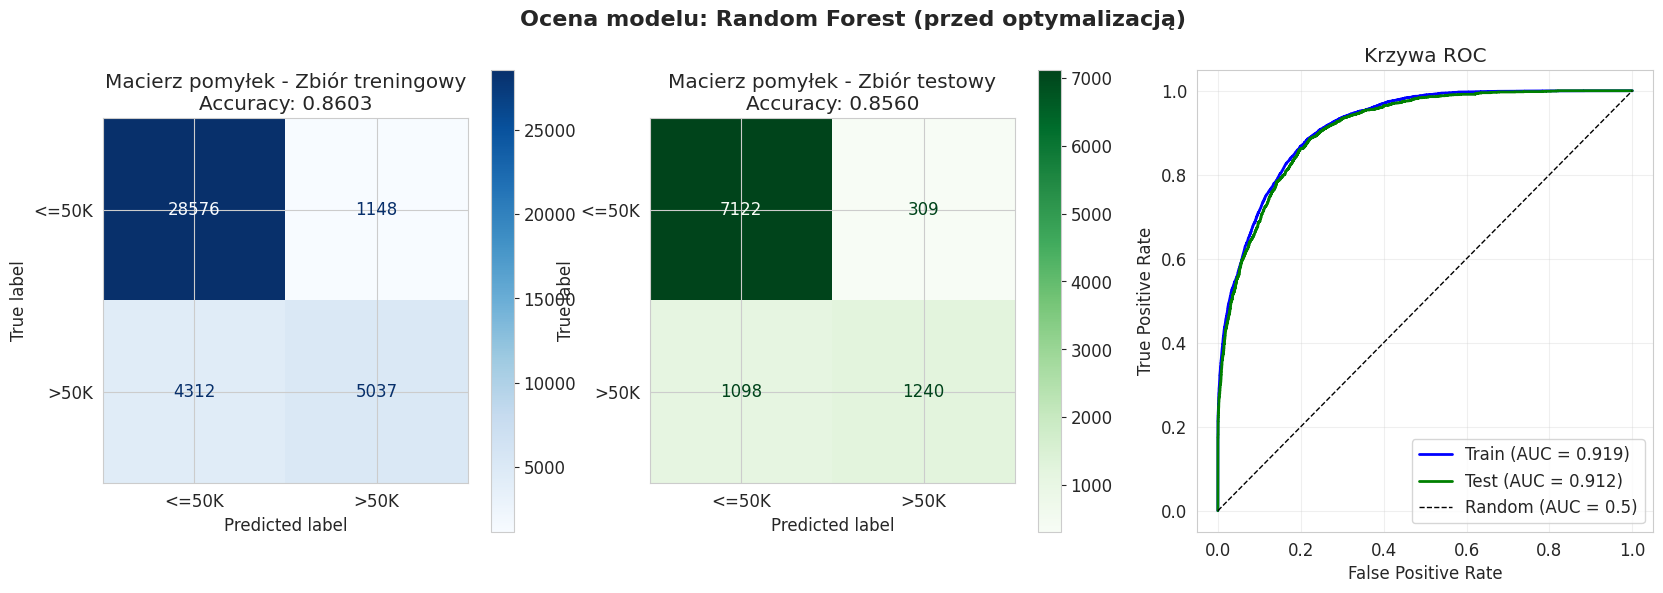

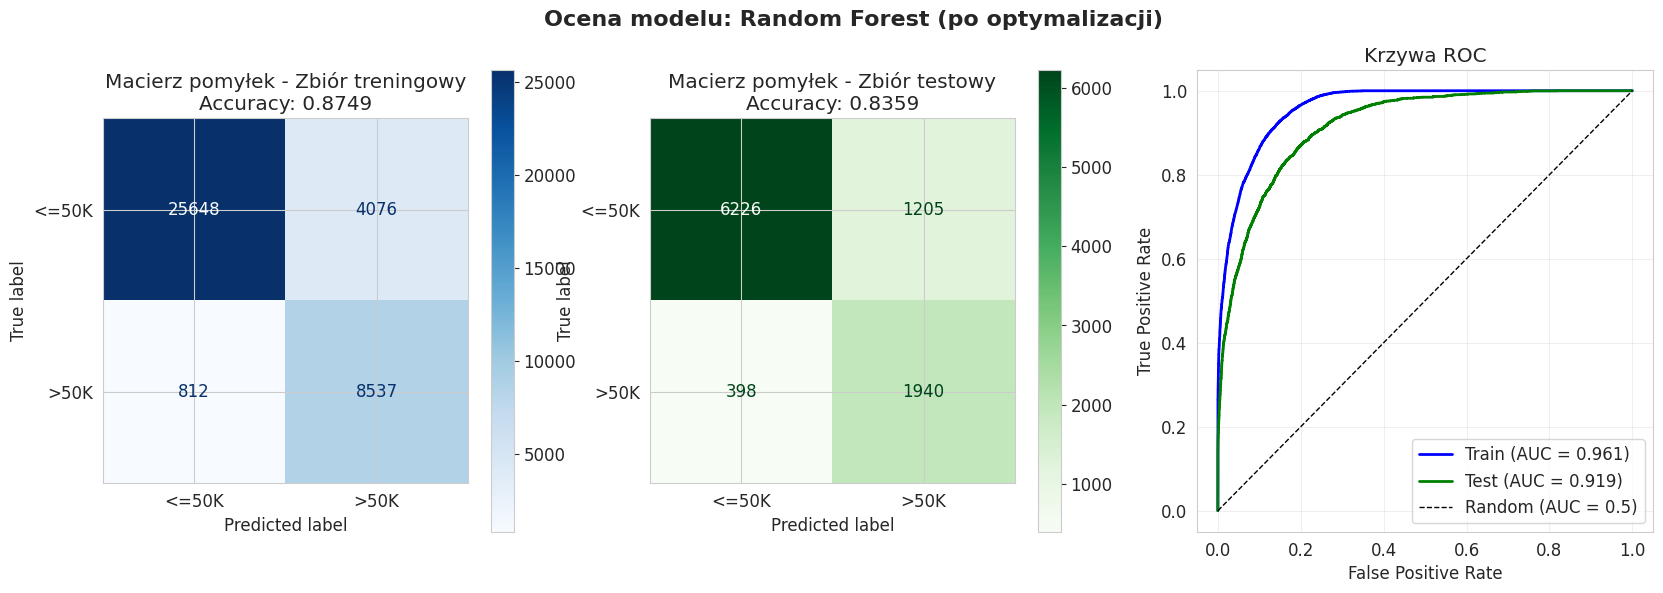

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, min_samples_split=5, max_depth=10)
rf_model.fit(X_train_processed, y_train)

rf_metrics_basic = evaluate_model(
    rf_model,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    "Random Forest (przed optymalizacją)"
)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,  # Testuje tylko 20 losowych kombinacji (zamiast wszystkich)
    cv=3,       # 3-krotna walidacja krzyżowa
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search_rf.fit(X_train_processed, y_train)

print(f"\nNajlepsze parametry: {random_search_rf.best_params_}")
print(f"Najlepszy wynik ROC AUC (trening): {random_search_rf.best_score_:.4f}")

rf_best = random_search_rf.best_estimator_

rf_metrics_opt = evaluate_model(
    rf_best,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    "Random Forest (po optymalizacji)"
)

### Logistic Regression (Regresja logistyczna)

OCENA MODELU: Logistic Regression

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8538
  • Precision (Precyzja):   0.7461
  • Recall (Czułość):       0.5899
  • F1-Score:               0.6589
  • ROC AUC:                0.9069

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8518
  • Precision (Precyzja):   0.7354
  • Recall (Czułość):       0.5945
  • F1-Score:               0.6575
  • ROC AUC:                0.9104
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Najlepsze parametry (LR): {'solver': 'liblinear', 'penalty': 'l2', 'C': 1}
Najlepszy wynik ROC AUC (LR): 0.9053
OCENA MODELU: Logistic Regression (po optymalizacji)

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8539
  • Precision (Precyzja):   0.7463
  • Recall (Czułość):       0.5900
  • F1-Score:               0.6590
  • ROC AUC:                0.9069

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8520
  • Precision (Precyzja):   0.7362
  • Recall (Czułoś

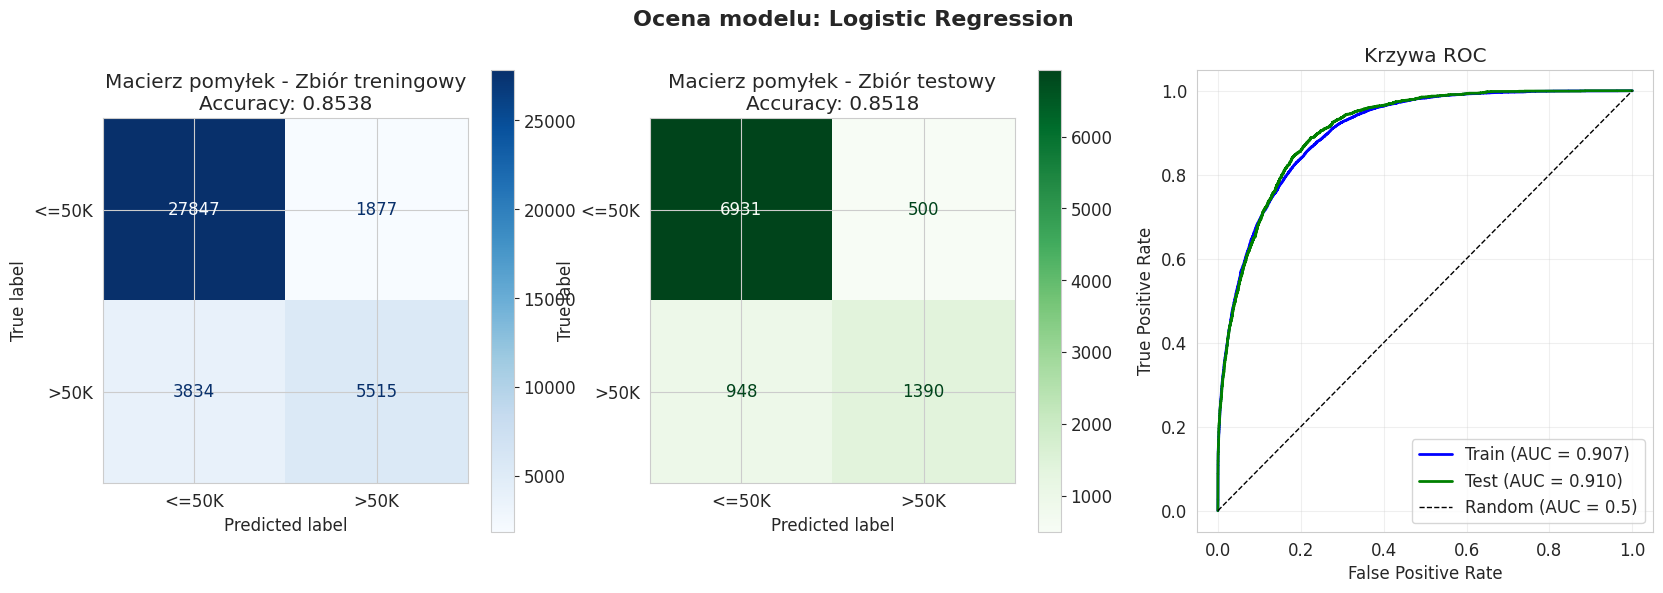

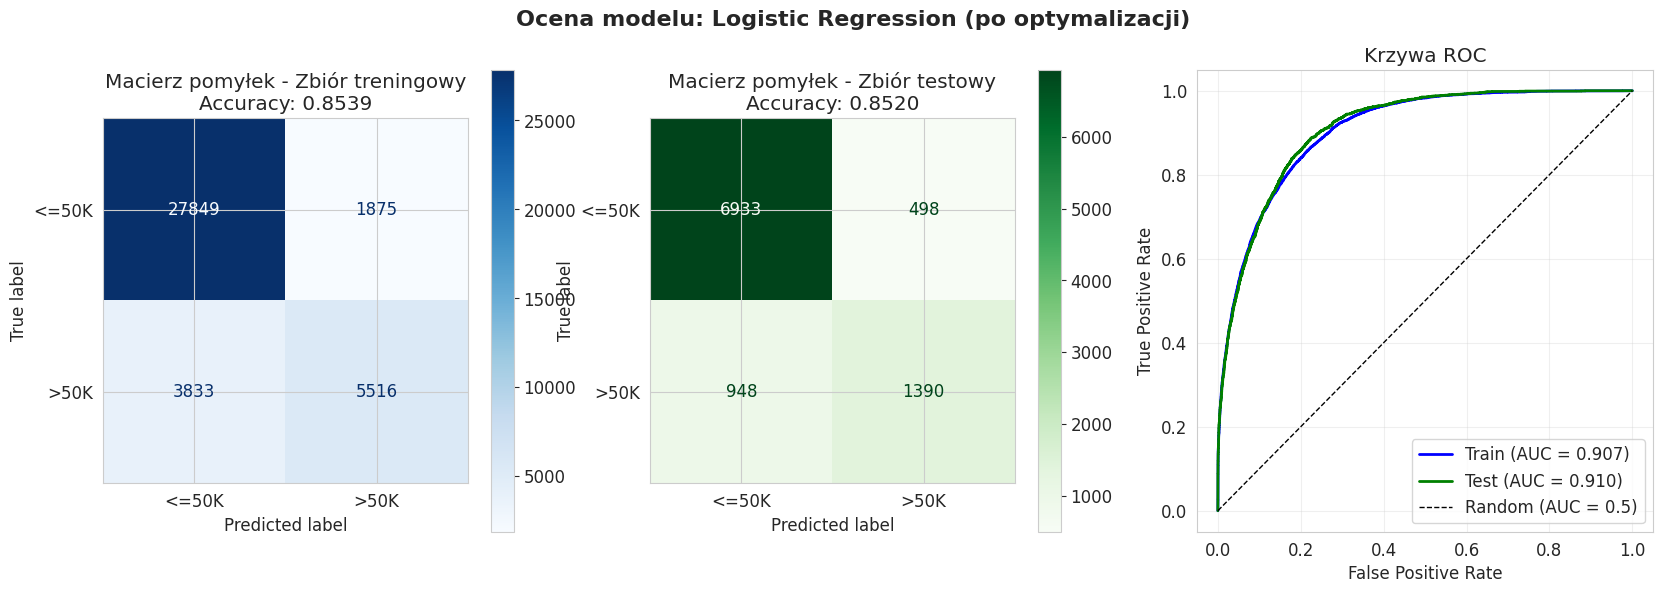

In [ ]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_processed, y_train)

lr_metrics_basic = evaluate_model(
    model_lr,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    "Logistic Regression"
)


param_dist_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # liblinear obsługuje dobrze l1 i l2 dla problemów binarnych
}

random_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000), # max_iter zwiększony dla zbieżności
    param_distributions=param_dist_lr,
    n_iter=10,        # 10 losowych prób
    cv=3,             # 3-krotna walidacja
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_lr.fit(X_train_processed, y_train)

print(f"\nNajlepsze parametry (LR): {random_search_lr.best_params_}")
print(f"Najlepszy wynik ROC AUC (LR): {random_search_lr.best_score_:.4f}")

lr_best = random_search_lr.best_estimator_

lr_metrics_opt = evaluate_model(
    lr_best,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    "Logistic Regression (po optymalizacji)"
)

### XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:46:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


OCENA MODELU: XGBoost

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8816
  • Precision (Precyzja):   0.8114
  • Recall (Czułość):       0.6579
  • F1-Score:               0.7266
  • ROC AUC:                0.9394

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8714
  • Precision (Precyzja):   0.7847
  • Recall (Czułość):       0.6377
  • F1-Score:               0.7036
  • ROC AUC:                0.9294
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:48:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Najlepsze parametry: {'subsample': 1.0, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
Najlepszy wynik ROC AUC (trening CV): 0.9271

--- Wyniki XGBoost po optymalizacji ---
OCENA MODELU: XGBoost (Optimized)

METRYKI NA ZBIORZE TRENINGOWYM:
  • Accuracy (Dokładność):  0.8840
  • Precision (Precyzja):   0.8106
  • Recall (Czułość):       0.6725
  • F1-Score:               0.7351
  • ROC AUC:                0.9408

METRYKI NA ZBIORZE TESTOWYM:
  • Accuracy (Dokładność):  0.8714
  • Precision (Precyzja):   0.7763
  • Recall (Czułość):       0.6501
  • F1-Score:               0.7076
  • ROC AUC:                0.9304


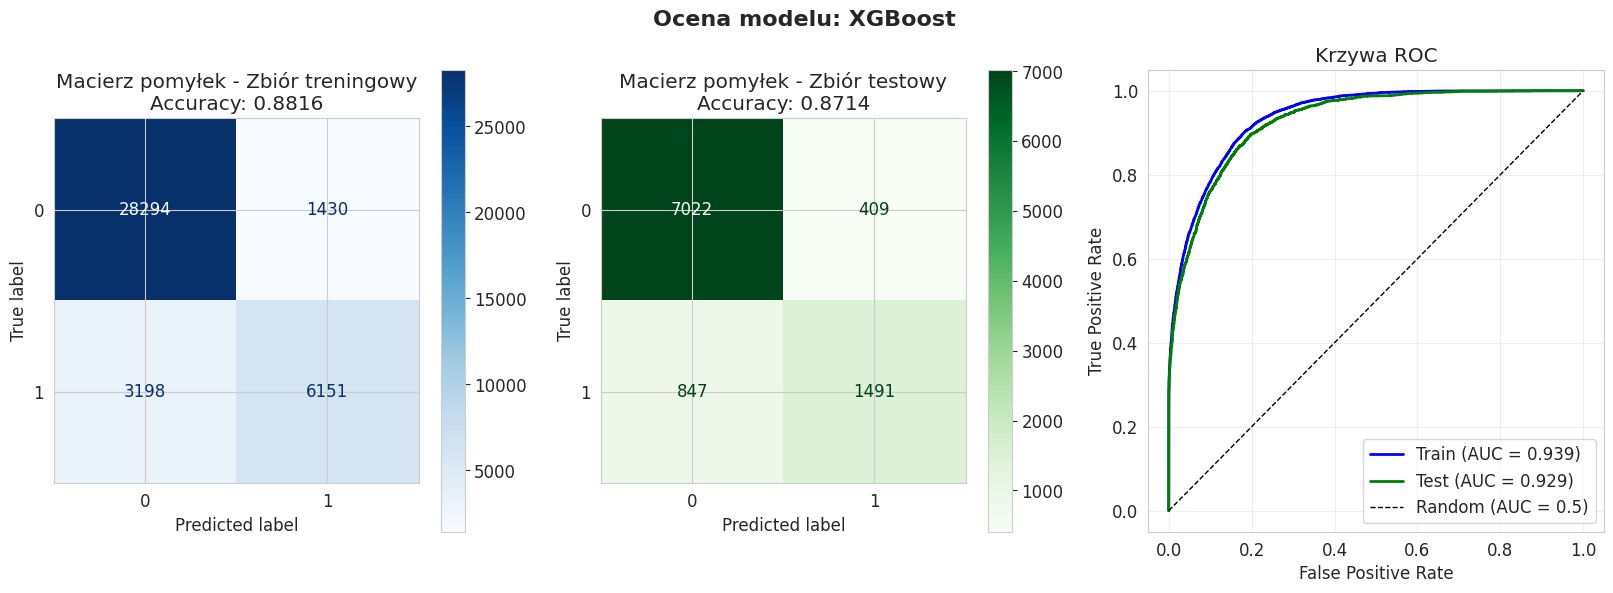

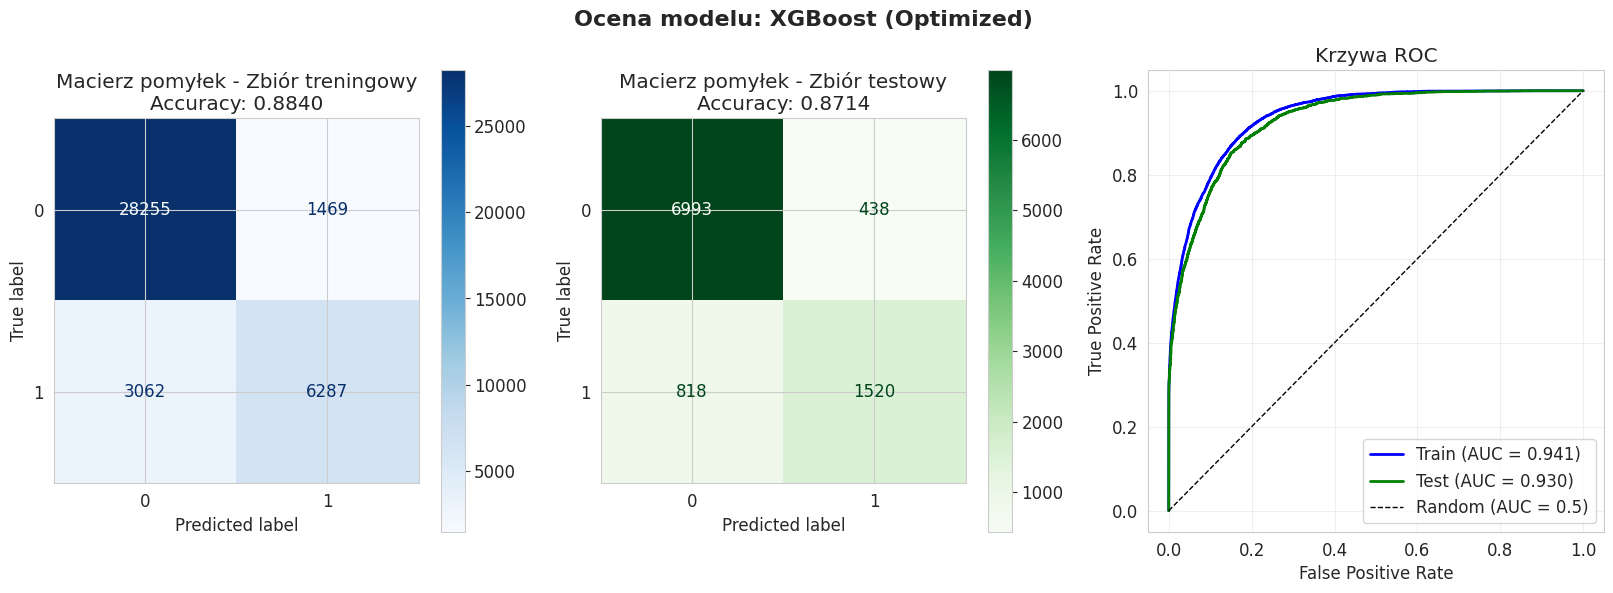

In [ ]:
model_xgb = XGBClassifier(
    n_estimators=100,        # liczba drzew (możesz zwiększyć do 200-500)
    max_depth=6,             # głębokość drzew
    learning_rate=0.1,       # tempo uczenia
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
y_train_binary = (y_train == '>50K').astype(int)
y_test_binary = (y_test == '>50K').astype(int)

model_xgb.fit(X_train_processed, y_train_binary)

xgb_metrics_basic = evaluate_model(
    model_xgb,
    X_train_processed,
    X_test_processed,
    y_train_binary,
    y_test_binary,
    "XGBoost",
    pos_label_metric=1
)


param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400],    # Więcej drzew może poprawić wynik
    'max_depth': [3, 5, 6, 8, 10],           # Płytsze drzewa = mniej overfittingu
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Wolniejsza nauka (0.01) często daje lepsze wyniki (wymaga więcej drzew)
    'subsample': [0.7, 0.8, 0.9, 1.0],       # Losowanie próbek (zapobiega overfittingowi)
    'colsample_bytree': [0.6, 0.8, 1.0],     # Losowanie cech na drzewo
    'gamma': [0, 0.1, 0.2]                   # Minimalna redukcja straty (regularyzacja)
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1 # XGBoost sam w sobie jest wielowątkowy, ale tu kontroluje to sklearn
    ),
    param_distributions=param_dist_xgb,
    n_iter=20,          # 20 losowych kombinacji - dobry kompromis czas/jakość
    cv=3,               # 3-krotna walidacja krzyżowa
    scoring='roc_auc',  # Optymalizujemy pod ROC AUC
    n_jobs=-1,          # Użycie wszystkich rdzeni do przeszukiwania siatki
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train_processed, y_train_binary)

print(f"Najlepsze parametry: {random_search_xgb.best_params_}")
print(f"Najlepszy wynik ROC AUC (trening CV): {random_search_xgb.best_score_:.4f}")

xgb_best = random_search_xgb.best_estimator_

print("\n--- Wyniki XGBoost po optymalizacji ---")
xgb_metrics_opt = evaluate_model(
    xgb_best,
    X_train_processed,
    X_test_processed,
    y_train_binary,
    y_test_binary,
    "XGBoost (Optimized)",
    pos_label_metric=1
)

#6. Wnioski końcowe
### 1. Najlepszy model
Z przeprowadzonych eksperymentów wynika, że **XGBoost (po optymalizacji)** okazał się najskuteczniejszym modelem.
- Osiągnął najwyższy wynik **ROC AUC (~0.93)**, co świadczy o jego doskonałej zdolności do rankowania klientów (oddzielania osób zarabiających >50K od reszty).
- Wykazał się również najwyższym **Accuracy (~87%)**, bijąc zarówno regresję logistyczną, jak i las losowy.

###2. Porównanie algorytmów
- **Logistic Regression:** Jako model bazowy poradził sobie przyzwoicie (ROC AUC ~0.90), ale ustępował modelom drzewiastym w wychwytywaniu nieliniowych zależności. Jest jednak najszybszy i najłatwiejszy w interpretacji.
- **Random Forest:** Zastosowanie wag klas (`class_weight='balanced'`) w optymalizacji pozwoliło mu osiągnąć bardzo wysoką czułość (**Recall ~83%**), co oznacza, że świetnie wykrywa osoby bogate, ale kosztem dużej liczby fałszywych alarmów (niska precyzja ~62%).
- **XGBoost:** Zapewnił najlepszy balans między precyzją a czułością (**F1-Score ~0.71**). Jest to model rekomendowany do wdrożenia produkcyjnego. Optymalizacja dała niewielki zysk na zbiorze testowym, ale potwierdziła stabilność modelu.

### 3. Wnioski biznesowe i zastosowanie
Stworzony model może być z powodzeniem wykorzystany w praktyce biznesowej, np.:
- **Marketing precyzyjny:** Banki lub firmy ubezpieczeniowe mogą używać modelu do typowania klientów, którym warto zaoferować produkty premium (karty kredytowe Gold/Platinum, fundusze inwestycyjne), nawet jeśli nie mają twardych danych o ich dochodach.
- **Analiza ryzyka:** Firmy pożyczkowe mogą wykorzystać predykcję "zarobki >50K" jako dodatkową zmienną w swoich modelach scoringowych (Credit Scoring).

### 4. Ważność cech (Feature Importance)
Analiza ważności cech w modelach drzewiastych potwierdziła, że kluczowymi predyktorami wysokich zarobków są:
1. **Stan cywilny (Marital Status):** Osoby w związku małżeńskim (`Married-civ-spouse`) znacznie częściej osiągają wysokie dochody gospodarstwa domowego.
2. **Zyski kapitałowe (Capital Gain):** Wysokie zyski z inwestycji są niemal pewnym wskaźnikiem zamożności.
3. **Edukacja (Education-Num):** Wyższy poziom wykształcenia silnie koreluje z wyższymi zarobkami.
4. **Wiek (Age):** Zarobki rosną wraz z doświadczeniem zawodowym (wiekiem), aż do momentu emerytury.

## Struktura projektu
1. **Wprowadzenie**
   - Cel projektu
   - Opis problemu biznesowego/naukowego

2. **Eksploracja i analiza danych**
   - Opis zbioru danych *ok*
   - Opis wszystkich zmiennych *ok*
   - Analiza brakujących wartości i wartości odstających *ok*
   - Analiza statystyczna zmiennych *ok*
   - Identyfikacja kluczowych zależności *ok*

3. **Wizualizacja danych**
   - Wizualizacje rozkładów wszystkich zmiennych *ok*
   - Wykresy zależności między zmiennymi objaśniającymi a docelowymi *ok*
   - Macierz korelacji dla zmiennych ciągłych *ok*
   - Wykresy pudełkowe dla analizy zmiennych kategorycznych *ok*
   - Podsumowanie i wnioski z analizy wizualnej
   Uwaga: Każdy wykres musi posiadać tytuł, nazwy osi, legendę i odpowiednie etykiety. *ok*

4. **Przetwarzanie danych**
   - Czyszczenie danych
   - Kodowanie zmiennych kategorycznych
   - Skalowanie i normalizacja
   - Feature engineering
   - Wybór zmiennych
   - Podział na zbiór treningowy i testowy
   - Jak największa część przetwarzania powinna być w pipeline'ach

5. **Budowa modelu**
   - Wybór i uzasadnienie wybranych modeli
   - Trenowanie modeli
   - Optymalizacja hiperparametrów
   - Ocena jakości modeli

6. **Wyniki i wnioski**
   - Podsumowanie wyników
   - Wnioski z analizy